# Week product-store demand classification with ADI and CV^2

This notebook classifies demand series from `data/processed/transactions_dst_over_weeks` into **smooth**, **erratic**, **intermittent**, and **lumpy** demand.

The default grain is one demand series per `ARTIKEL_ID` and `MARKT_ID`. For product-level demand aggregated across all stores instead, set `GROUP_COLS = ["ARTIKEL_ID"]`.

`DATE` is interpreted as the Monday week-start date. Generate the dataset first with `python src/data/preparation/distribute_sales_over_active_weeks.py`.

## Why weekly aggregation is needed

The daily product-store grain is technically usable for an intermittent-demand benchmark, but it is a weak first baseline target for regular time-series models. The daily ADI/CV^2 EDA showed:

- only **5.9%** regular-demand series (`smooth + erratic`),
- **94.1%** sparse-demand series (`intermittent + lumpy`),
- about **77.1%** zero observations at the active product-store daily grain,
- median daily product-store ADI around **6.43**.

A daily product-store model can therefore look acceptable on MAE by predicting zeros, while still missing the timing and size of actual sales. Weekly aggregation reduces zero inflation and gives a more stable baseline target. Direct product-store weekly demand can still be sparse; product-level weekly demand or a product-level forecast allocated back to stores should also be evaluated.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
DEMAND_COL = "ABVERKAUFTE_MENGE_KG"
MIN_DEMAND_PERIODS = 10
ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49

candidate_dirs = [
    Path("../../data/processed/transactions_dst_over_weeks"),
    Path("../data/processed/transactions_dst_over_weeks"),
    Path("data/processed/transactions_dst_over_weeks"),
]
DATA_DIR = next((path for path in candidate_dirs if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the processed week transactions directory. "
        "Run src/data/preparation/distribute_sales_over_active_weeks.py first."
    )

parquet_files = sorted(DATA_DIR.glob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")

print(f"Using {len(parquet_files)} parquet files from {DATA_DIR}")
print(f"Classifying demand series at grain: {', '.join(GROUP_COLS)}")

Using 2 parquet files from ../../data/processed/transactions_dst_over_weeks
Classifying demand series at grain: ARTIKEL_ID, MARKT_ID


## Method

For each demand series:

- **ADI** is `active_weeks / demand_weeks`, where demand weeks have sold quantity above zero.
- **CV^2** is `variance(non-zero demand) / mean(non-zero demand)^2`.
- **Smooth**: `ADI < 1.32` and `CV^2 < 0.49`.
- **Erratic**: `ADI < 1.32` and `CV^2 >= 0.49`.
- **Intermittent**: `ADI >= 1.32` and `CV^2 < 0.49`.
- **Lumpy**: `ADI >= 1.32` and `CV^2 >= 0.49`.

Rows with zero sold amount are retained as active no-sale weeks, as intended by the prepared data. Series with fewer than `MIN_DEMAND_PERIODS` demand weeks are excluded from the summary.

In [2]:
group_cols_sql = ", ".join(GROUP_COLS)
period_group_cols_sql = ", ".join([*GROUP_COLS, "period_start"])
parquet_glob = str(DATA_DIR / "*.parquet")

query = f"""
WITH raw AS (
    SELECT
        {group_cols_sql},
        CAST(DATE AS DATE) AS period_start,
        CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE) AS demand
    FROM read_parquet(?)
), period_data AS (
    SELECT
        {period_group_cols_sql},
        SUM(demand) AS demand
    FROM raw
    GROUP BY {period_group_cols_sql}
), series AS (
    SELECT
        {group_cols_sql},
        COUNT(*) AS active_weeks,
        SUM(CASE WHEN demand > 0 THEN 1 ELSE 0 END) AS demand_weeks,
        SUM(demand) AS series_total_demand,
        AVG(CASE WHEN demand > 0 THEN demand END) AS mean_nonzero_demand,
        VAR_SAMP(CASE WHEN demand > 0 THEN demand END) AS var_nonzero_demand,
        MIN(period_start) AS first_active_week,
        MAX(period_start) AS last_active_week
    FROM period_data
    GROUP BY {group_cols_sql}
)
SELECT
    *,
    active_weeks / NULLIF(demand_weeks, 0) AS ADI,
    CASE
        WHEN demand_weeks > 1 AND mean_nonzero_demand > 0
            THEN var_nonzero_demand / (mean_nonzero_demand * mean_nonzero_demand)
        WHEN demand_weeks = 1 THEN 0.0
        ELSE NULL
    END AS CV2
FROM series
WHERE demand_weeks > 0
"""

con = duckdb.connect()
series_metrics = con.execute(query, [parquet_glob]).fetchdf()
series_metrics.head()

,ARTIKEL_ID,MARKT_ID,active_weeks,demand_weeks,series_total_demand,mean_nonzero_demand,var_nonzero_demand,first_active_week,last_active_week,ADI,CV2
0,1382766,1300023,60,60.0,240.0170,4.000283,2.754461,2025-05-12,2026-06-29,1.000000,0.172129
1,1399512,1100039,46,23.0,18.6940,0.812783,0.242393,2025-08-11,2026-06-22,2.000000,0.366920
2,1382777,1100051,50,49.0,53.4840,1.091510,0.453990,2025-07-21,2026-06-29,1.020408,0.381058
3,1402822,1100045,31,14.0,35.4726,2.533757,1.979842,2025-09-15,2026-04-13,2.214286,0.308390
4,1413151,1300023,29,20.0,16.6020,0.830100,0.709684,2025-12-08,2026-06-22,1.450000,1.029922


In [3]:
conditions = [
    (series_metrics["ADI"] < ADI_CUTOFF) & (series_metrics["CV2"] < CV2_CUTOFF),
    (series_metrics["ADI"] < ADI_CUTOFF) & (series_metrics["CV2"] >= CV2_CUTOFF),
    (series_metrics["ADI"] >= ADI_CUTOFF) & (series_metrics["CV2"] < CV2_CUTOFF),
    (series_metrics["ADI"] >= ADI_CUTOFF) & (series_metrics["CV2"] >= CV2_CUTOFF),
]
choices = ["smooth", "erratic", "intermittent", "lumpy"]

series_classification = series_metrics.assign(
    demand_class=np.select(conditions, choices, default="unclassified")
)
series_classification = series_classification[
    series_classification["demand_weeks"] >= MIN_DEMAND_PERIODS
]

class_order = ["smooth", "erratic", "intermittent", "lumpy"]
class_palette = {
    "smooth": "#2a9d8f",
    "erratic": "#e9c46a",
    "intermittent": "#457b9d",
    "lumpy": "#d62828",
}

product_agg = ("ARTIKEL_ID", "nunique") if "ARTIKEL_ID" in GROUP_COLS else (GROUP_COLS[0], "nunique")
summary = (
    series_classification
    .groupby("demand_class", observed=True)
    .agg(
        series=(GROUP_COLS[0], "size"),
        products=product_agg,
        active_weeks=("active_weeks", "sum"),
        demand_weeks=("demand_weeks", "sum"),
        median_ADI=("ADI", "median"),
        median_CV2=("CV2", "median"),
    )
    .reindex(class_order)
)
summary["series_share"] = summary["series"] / summary["series"].sum()
summary["observation_share"] = summary["active_weeks"] / summary["active_weeks"].sum()

summary_display = summary.copy()
for col in ["series_share", "observation_share"]:
    summary_display[col] = (summary_display[col] * 100).round(1)
summary_display[["median_ADI", "median_CV2"]] = summary_display[["median_ADI", "median_CV2"]].round(2)
summary_display.rename(
    columns={
        "series_share": "series_share_%",
        "observation_share": "observation_share_%",
    }
)

,series,products,active_weeks,demand_weeks,median_ADI,median_CV2,series_share_%,observation_share_%
demand_class,,,,,,,,
smooth,60,18,2848,2696.0,1.03,0.32,37.7,43.0
erratic,20,12,866,767.0,1.12,0.63,12.6,13.1
intermittent,34,12,1058,581.0,1.80,0.30,21.4,16.0
lumpy,45,14,1857,1036.0,1.64,0.81,28.3,28.0


In [4]:
regular_share = summary.loc[["smooth", "erratic"], "series"].sum() / summary["series"].sum()
sparse_share = summary.loc[["intermittent", "lumpy"], "series"].sum() / summary["series"].sum()
zero_period_share = 1 - (series_classification["demand_weeks"].sum() / series_classification["active_weeks"].sum())

print(f"Total classified series: {len(series_classification):,}")
print(f"Regular-demand share (smooth + erratic): {regular_share:.1%}")
print(f"Sparse-demand share (intermittent + lumpy): {sparse_share:.1%}")
print(f"Zero active-period share: {zero_period_share:.1%}")

Total classified series: 159
Regular-demand share (smooth + erratic): 50.3%
Sparse-demand share (intermittent + lumpy): 49.7%
Zero active-period share: 23.4%


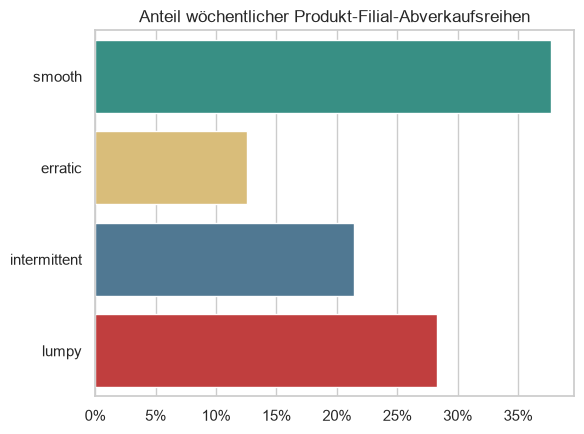

In [5]:
plot_summary = summary.reset_index()

fig, ax = plt.subplots(figsize=(6, 4.5))

sns.barplot(
    data=plot_summary,
    y="demand_class",
    x="series_share",
    order=class_order,
    palette=class_palette,
    hue="demand_class",
    hue_order=class_order,
    legend=False,
    ax=ax,
)

ax.set_title("Anteil wöchentlicher Produkt-Filial-Abverkaufsreihen")
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.tight_layout()

In [6]:
quantiles = (
    series_classification
    .groupby("demand_class", observed=True)[["ADI", "CV2", "active_weeks", "demand_weeks"]]
    .quantile([0.25, 0.50, 0.75])
    .round(2)
)
quantiles

ADI   CV2  active_weeks  demand_weeks
demand_class                                             
erratic      0.25  1.06  0.53         23.75         21.75
             0.50  1.12  0.63         49.00         42.00
             0.75  1.20  0.80         57.50         50.00
intermittent 0.25  1.57  0.23         24.00         13.00
             0.50  1.80  0.30         26.00         14.50
             0.75  2.03  0.36         30.75         18.75
lumpy        0.25  1.43  0.68         34.00         14.00
             0.50  1.64  0.81         42.00         24.00
             0.75  2.05  1.08         51.00         30.00
smooth       0.25  1.00  0.22         36.50         30.50
             0.50  1.03  0.32         56.00         52.50
             0.75  1.09  0.41         58.00         57.00

## Baseline implication

Use this week product-store classification to decide which baselines are fair:

- smooth/erratic series can be evaluated with simple seasonal naive and moving-average baselines;
- intermittent/lumpy series need sparse-demand baselines such as zero, last non-zero demand, Croston/SBA/TSB-style methods, or a two-stage demand-occurrence plus demand-size baseline;
- compare direct product-store forecasting against a product-level forecast allocated to stores by recent store shares.